In [1]:
# load_discrete_sb3_policies.py
#
# Install:
#   pip install "stable-baselines3>=2.3.0" huggingface-sb3 gymnasium torch
#   pip install "gymnasium[box2d]"   # only needed for LunarLander
#
# Example:
#   bundle = load_policy_bundle("ppo", "CartPole-v1")
#   actor_logits = bundle.actor(obs_tensor)
#   critic_value = bundle.critic(obs_tensor)
#
#   bundle = load_policy_bundle("dqn", "MountainCar-v0")
#   q_values = bundle.q_net(obs_tensor)

from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Literal

import gymnasium as gym
import torch
import torch.nn as nn
from gymnasium import spaces
from huggingface_sb3 import load_from_hub
from stable_baselines3 import DQN, PPO
import matplotlib.pyplot as plt


Algo = Literal["dqn", "ppo"]


# SB3/RL-Zoo Hugging Face checkpoints for discrete-action environments.
# These are Gymnasium-compatible classic-control / Box2D-style environments.
HF_SB3_MODELS: dict[str, dict[str, tuple[str, str]]] = {
    "dqn": {
        "CartPole-v1": ("sb3/dqn-CartPole-v1", "dqn-CartPole-v1.zip"),
        "MountainCar-v0": ("sb3/dqn-MountainCar-v0", "dqn-MountainCar-v0.zip"),
        "Acrobot-v1": ("sb3/dqn-Acrobot-v1", "dqn-Acrobot-v1.zip"),
        "LunarLander-v2": ("sb3/dqn-LunarLander-v2", "dqn-LunarLander-v2.zip"),
    },
    "ppo": {
        "CartPole-v1": ("sb3/ppo-CartPole-v1", "ppo-CartPole-v1.zip"),
        "MountainCar-v0": ("sb3/ppo-MountainCar-v0", "ppo-MountainCar-v0.zip"),
        "Acrobot-v1": ("sb3/ppo-Acrobot-v1", "ppo-Acrobot-v1.zip"),
        "LunarLander-v2": ("sb3/ppo-LunarLander-v2", "ppo-LunarLander-v2.zip"),
    },
}


def make_env_compat(env_id: str) -> gym.Env:
    """
    Make a Gymnasium env.

    Note:
    Some HF SB3 checkpoints are named with old Gym IDs such as LunarLander-v2.
    If your installed Gymnasium version only exposes LunarLander-v3, this helper
    falls back to LunarLander-v3 while still loading the old checkpoint.
    """
    try:
        return gym.make(env_id)
    except Exception as original_error:
        if env_id == "LunarLander-v2":
            try:
                return gym.make("LunarLander-v3")
            except Exception:
                raise original_error
        raise original_error


class PPOActorLogits(nn.Module):
    """
    Verification-friendly PPO actor wrapper.

    Input:
        obs: torch.Tensor, shape [batch, obs_dim] for MLP policies,
             or [batch, channels, height, width] for CNN policies.

    Output:
        logits: torch.Tensor, shape [batch, n_actions]

    For discrete-action PPO, SB3 represents the actor as a categorical policy.
    The action logits are obtained from:
        features -> actor latent -> action_net.
    """

    def __init__(self, ppo_model: PPO):
        super().__init__()
        self.policy = ppo_model.policy

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        features = self.policy.extract_features(obs)

        # Most SB3 ActorCriticPolicy models share one feature extractor.
        # Non-shared feature extractors return a tuple.
        if isinstance(features, tuple):
            features_pi, _features_vf = features
            latent_pi = self.policy.mlp_extractor.forward_actor(features_pi)
        else:
            latent_pi, _latent_vf = self.policy.mlp_extractor(features)

        logits = self.policy.action_net(latent_pi)
        return logits


class PPOCriticValue(nn.Module):
    """
    Verification-friendly PPO critic wrapper.

    Input:
        obs: torch.Tensor

    Output:
        value: torch.Tensor, shape [batch, 1]

    This returns V(s), not Q(s,a).
    """

    def __init__(self, ppo_model: PPO):
        super().__init__()
        self.policy = ppo_model.policy

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        features = self.policy.extract_features(obs)

        if isinstance(features, tuple):
            _features_pi, features_vf = features
            latent_vf = self.policy.mlp_extractor.forward_critic(features_vf)
        else:
            _latent_pi, latent_vf = self.policy.mlp_extractor(features)

        value = self.policy.value_net(latent_vf)
        return value


class DQNQValues(nn.Module):
    """
    Verification-friendly DQN wrapper.

    Input:
        obs: torch.Tensor

    Output:
        q_values: torch.Tensor, shape [batch, n_actions]

    The greedy DQN policy is:
        argmax_a Q(s,a).
    """

    def __init__(self, dqn_model: DQN):
        super().__init__()
        self.q_net = dqn_model.q_net

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.q_net(obs)


@dataclass
class LoadedPolicyBundle:
    algo: str
    env_id: str
    env: gym.Env
    model: DQN | PPO

    # DQN
    q_net: Optional[nn.Module] = None

    # PPO
    actor: Optional[nn.Module] = None
    critic: Optional[nn.Module] = None


def load_policy_bundle(
    algo: Algo,
    env_id: str,
    device: str | torch.device = "cpu",
) -> LoadedPolicyBundle:
    """
    Load a pretrained SB3/RL-Zoo Hugging Face model and expose useful modules.

    For DQN:
        returns bundle.q_net(obs) -> Q-values.

    For PPO:
        returns bundle.actor(obs)  -> action logits.
        returns bundle.critic(obs) -> state value V(s).

    The loaded environment must have a discrete action space.
    """
    algo = algo.lower()
    if algo not in HF_SB3_MODELS:
        raise ValueError(f"Unknown algo={algo!r}. Expected one of {list(HF_SB3_MODELS)}.")

    if env_id not in HF_SB3_MODELS[algo]:
        available = sorted(HF_SB3_MODELS[algo])
        raise ValueError(
            f"No registered HF/SB3 checkpoint for algo={algo!r}, env_id={env_id!r}.\n"
            f"Available envs: {available}"
        )

    env = make_env_compat(env_id)

    if not isinstance(env.action_space, spaces.Discrete):
        raise TypeError(
            f"{env_id} does not have a discrete action space. "
            f"Got: {env.action_space}"
        )

    repo_id, filename = HF_SB3_MODELS[algo][env_id]
    checkpoint = load_from_hub(repo_id=repo_id, filename=filename)

    # Important for old Gym checkpoints loaded under modern Gymnasium:
    # replace serialized observation/action spaces with the current env spaces.
    custom_objects = {
        "observation_space": env.observation_space,
        "action_space": env.action_space,
    }

    if algo == "dqn":
        model = DQN.load(
            checkpoint,
            env=env,
            device=device,
            custom_objects=custom_objects,
        )
        model.policy.eval()
        q_net = DQNQValues(model).to(device).eval()

        return LoadedPolicyBundle(
            algo=algo,
            env_id=env_id,
            env=env,
            model=model,
            q_net=q_net,
        )

    if algo == "ppo":
        model = PPO.load(
            checkpoint,
            env=env,
            device=device,
            custom_objects=custom_objects,
        )
        model.policy.eval()
        actor = PPOActorLogits(model).to(device).eval()
        critic = PPOCriticValue(model).to(device).eval()

        return LoadedPolicyBundle(
            algo=algo,
            env_id=env_id,
            env=env,
            model=model,
            actor=actor,
            critic=critic,
        )

    raise RuntimeError("Unreachable.")


@torch.no_grad()
def sanity_check(bundle: LoadedPolicyBundle, device: str | torch.device = "cpu") -> None:
    """
    Run one observation through the loaded network.
    """
    obs, _info = bundle.env.reset()

    obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

    print(f"Loaded {bundle.algo.upper()} for {bundle.env_id}")
    print(f"Observation shape: {tuple(obs_tensor.shape)}")
    print(f"Action space: {bundle.env.action_space}")

    if bundle.algo == "dqn":
        assert bundle.q_net is not None
        q_values = bundle.q_net(obs_tensor)
        greedy_action = torch.argmax(q_values, dim=-1)
        print("Q-values:", q_values.cpu().numpy())
        print("Greedy action:", greedy_action.cpu().numpy())

    elif bundle.algo == "ppo":
        assert bundle.actor is not None
        assert bundle.critic is not None
        logits = bundle.actor(obs_tensor)
        value = bundle.critic(obs_tensor)
        greedy_action = torch.argmax(logits, dim=-1)
        print("Actor logits:", logits.cpu().numpy())
        print("Critic V(s):", value.cpu().numpy())
        print("Greedy action from logits:", greedy_action.cpu().numpy())


# if __name__ == "__main__":
device = "cpu"

# DQN examples: discrete-action Q-networks.
dqn_cartpole = load_policy_bundle("dqn", "CartPole-v1", device=device)
sanity_check(dqn_cartpole, device=device)

dqn_mountaincar = load_policy_bundle("dqn", "MountainCar-v0", device=device)
sanity_check(dqn_mountaincar, device=device)

# PPO examples: actor logits + critic V(s).
ppo_cartpole = load_policy_bundle("ppo", "CartPole-v1", device=device)
sanity_check(ppo_cartpole, device=device)

ppo_acrobot = load_policy_bundle("ppo", "Acrobot-v1", device=device)
sanity_check(ppo_acrobot, device=device)

I0000 00:00:1781956699.198686 1916054 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781956699.283670 1916054 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781956706.972389 1916054 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/.venv/lib/python3.10/site-packages/stable_baselines3

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/.venv/lib/python3.10/site-packages/stable_baselines3/common/base_class.py:773: UserWarning: You are probably loading a DQN model saved with SB3 < 2.4.0, we truncated the optimizer state so you can save the model again to avoid issues in the future (see https://github.com/DLR-RM/stable-baselines3/pull/1963 for more info). Original error: loaded state dict contains a parameter group that doesn't match the size of optimizer's group 
Note: the model should still work fine, this only a warning.
  warnings.warn(
/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/.venv/lib/python3.10/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object learning_rate. Consider using `custom_objects` argument to replace this object.
Exception: 'bytes' object cannot be interpreted as an integer
  warnings.warn(
/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/.venv/lib/python3.10/site-packag

Loaded DQN for CartPole-v1
Observation shape: (1, 4)
Action space: Discrete(2)
Q-values: [[105.1655 105.3499]]
Greedy action: [1]
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Loaded DQN for MountainCar-v0
Observation shape: (1, 2)
Action space: Discrete(3)
Q-values: [[-44.59754  -44.322594 -44.01037 ]]
Greedy action: [2]
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Loaded PPO for CartPole-v1
Observation shape: (1, 4)
Action space: Discrete(2)
Actor logits: [[-0.2578047  0.2599142]]
Critic V(s): [[50.005203]]
Greedy action from logits: [1]
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Loaded PPO for Acrobot-v1
Observation shape: (1, 6)
Action space: Discrete(3)
Actor logits: [[ 5.9884443 -3.6294284 -1.3522283]]
Critic V(s): [[-2.6464753]]
Greedy action from logits: [0]


/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/.venv/lib/python3.10/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: 'bytes' object cannot be interpreted as an integer
  warnings.warn(


In [15]:
from pathlib import Path

import numpy as np
from IPython.display import Image as NotebookImage, display
from PIL import Image as PILImage


def make_rollout_env(env_id: str, render_mode: str | None = None) -> gym.Env:
    kwargs = {"render_mode": render_mode} if render_mode is not None else {}
    try:
        return gym.make(env_id, **kwargs)
    except Exception as original_error:
        if env_id == "LunarLander-v2":
            try:
                return gym.make("LunarLander-v3", **kwargs)
            except Exception:
                raise original_error
        raise original_error


def run_deployment_episode(
    bundle: LoadedPolicyBundle,
    *,
    seed: int = 0,
    deterministic: bool = True,
    render: bool = False,
    frame_stride: int = 1,
    max_steps: int | None = None,
) -> tuple[list[np.ndarray], dict[str, float | int | bool]]:
    env = make_rollout_env(bundle.env_id, render_mode="rgb_array" if render else None)
    frames: list[np.ndarray] = []

    try:
        obs, _info = env.reset(seed=seed)
        if render:
            frame = env.render()
            if frame is not None:
                frames.append(np.asarray(frame, dtype=np.uint8))

        spec = getattr(env, "spec", None)
        episode_limit = max_steps or getattr(spec, "max_episode_steps", None) or 1_000
        total_reward = 0.0
        terminated = False
        truncated = False
        steps = 0

        while not (terminated or truncated) and steps < episode_limit:
            action, _state = bundle.model.predict(obs, deterministic=deterministic)
            if isinstance(env.action_space, spaces.Discrete):
                action = int(np.asarray(action).item())

            obs, reward, terminated, truncated, _info = env.step(action)
            total_reward += float(reward)
            steps += 1

            if render and (steps % frame_stride == 0 or terminated or truncated):
                frame = env.render()
                if frame is not None:
                    frames.append(np.asarray(frame, dtype=np.uint8))

        stats = {
            "return": total_reward,
            "steps": steps,
            "terminated": terminated,
            "truncated": truncated,
        }
        return frames, stats
    finally:
        env.close()


def save_deployment_gif(
    bundle: LoadedPolicyBundle,
    *,
    save_dir: str | Path = "artifacts/policy_rollouts",
    seed: int = 0,
    fps: int = 30,
    frame_stride: int = 2,
) -> tuple[Path, dict[str, float | int | bool]]:
    frames, stats = run_deployment_episode(
        bundle,
        seed=seed,
        render=True,
        frame_stride=frame_stride,
    )
    if not frames:
        raise RuntimeError("No frames were captured. Check that the env supports render_mode='rgb_array'.")

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    safe_env_id = bundle.env_id.replace("/", "_")
    gif_path = save_dir / f"{bundle.algo}_{safe_env_id}_deployment_seed{seed}.gif"

    pil_frames = [PILImage.fromarray(frame) for frame in frames]
    pil_frames[0].save(
        gif_path,
        save_all=True,
        append_images=pil_frames[1:],
        duration=max(1, int(1000 / fps)),
        loop=0,
    )
    return gif_path, stats


loaded_bundles = [dqn_cartpole, dqn_mountaincar, ppo_cartpole, ppo_acrobot]

# Run each loaded policy once in its matching environment.
rollout_summaries = {}
for bundle in loaded_bundles:
    _frames, stats = run_deployment_episode(bundle, seed=42)
    rollout_summaries[f"{bundle.algo.upper()} {bundle.env_id}"] = stats
    print(f"{bundle.algo.upper():>3} {bundle.env_id:<16} return={stats['return']:.1f} steps={stats['steps']}")

# # Save one deployment episode as a GIF. Switch this to any bundle above.
# deployment_bundle = ppo_cartpole
# gif_path, gif_stats = save_deployment_gif(deployment_bundle, seed=42, fps=30, frame_stride=2)
# print(f"Saved GIF to: {gif_path} | stats={gif_stats}")
# display(NotebookImage(filename=str(gif_path)))

rollout_summaries

DQN CartPole-v1      return=500.0 steps=500
DQN MountainCar-v0   return=-200.0 steps=200
PPO CartPole-v1      return=500.0 steps=500
PPO Acrobot-v1       return=-72.0 steps=73


{'DQN CartPole-v1': {'return': 500.0,
  'steps': 500,
  'terminated': False,
  'truncated': True},
 'DQN MountainCar-v0': {'return': -200.0,
  'steps': 200,
  'terminated': False,
  'truncated': True},
 'PPO CartPole-v1': {'return': 500.0,
  'steps': 500,
  'terminated': False,
  'truncated': True},
 'PPO Acrobot-v1': {'return': -72.0,
  'steps': 73,
  'terminated': True,
  'truncated': False}}

### Mountain Car: safety verification

ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


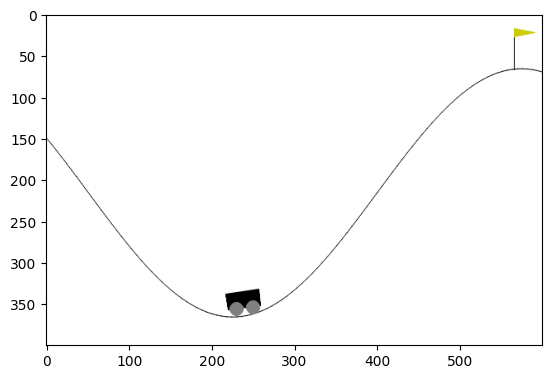

In [16]:
env = gym.make('MountainCar-v0', render_mode='rgb_array')
obs, info = env.reset()
frame = env.render()
plt.imshow(frame)


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


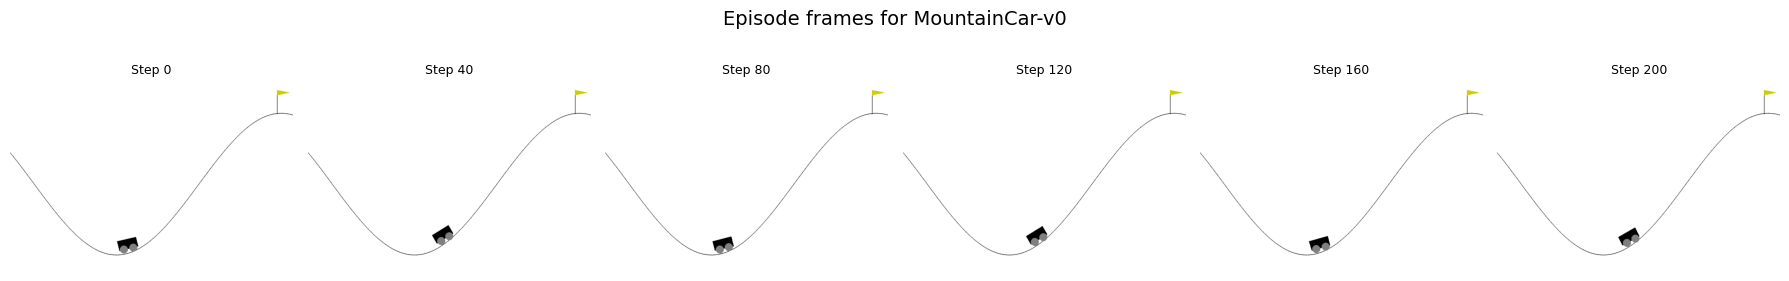

In [ ]:
_ = plot_episode(
    actor=dqn_mountaincar.q_net,
    env_id='MountainCar-v0',
    # env: gymnasium.Env | None = None,
    n_cols=6,
    one_row=True,
    # log_std: torch.nn.Parameter | None = None,
    # deterministic: bool = True,
    # seed: int = 42,
    # env_kwargs: dict | None = None,
    # save_path: str | None = None,
    # figsize_per_frame: tuple[float, float] = (3.0, 3.0),
    # title: str | None = None,
)

In [5]:
env.observation_space

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

In [6]:
import copy
import sys
from pathlib import Path

import torch
import torch.nn as nn

# Make repo package importable if the notebook kernel was not started from repo root.
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in (start, *start.parents):
        if (candidate / "core").is_dir() and (candidate / "tutorials").is_dir():
            return candidate
    raise RuntimeError("Could not locate repo root.")

REPO_ROOT = find_repo_root()
CORE_DIR = REPO_ROOT / "core"
if str(CORE_DIR) not in sys.path:
    sys.path.insert(0, str(CORE_DIR))

from abstract_gradient_training.bounded_models import CROWNBoundedModel, IntervalBoundedModel

device = torch.device("cpu")

# DQN MountainCar produces action scores / Q-values. Treat these as the policy "logits".
# SB3's verification-friendly part is the underlying nn.Sequential Q-network.
mountaincar_q_net = copy.deepcopy(dqn_mountaincar.model.q_net.q_net).to(device).eval()

unsupported = [
    type(layer).__name__
    for layer in mountaincar_q_net
    if not isinstance(layer, (nn.Linear, nn.ReLU))
]
if unsupported:
    raise TypeError(f"Verifier does not support these layers: {unsupported}")

# MountainCar observation = [position, velocity].
# Position interval requested by you. Note: standard MountainCar's env max position is 0.6,
# but this intentionally verifies the wider interval ending at 1.0.
position_interval = (-1.2, -1.0)

# Verify over all valid velocities. For a zero-velocity slice, use (0.0, 0.0).
velocity_interval = (
    float(dqn_mountaincar.env.observation_space.low[1]),
    float(dqn_mountaincar.env.observation_space.high[1]),
)

input_l = torch.tensor(
    [[position_interval[0], velocity_interval[0]]],
    dtype=torch.float32,
    device=device,
)
input_u = torch.tensor(
    [[position_interval[1], velocity_interval[1]]],
    dtype=torch.float32,
    device=device,
)

def make_verifier(method: str):
    model = copy.deepcopy(mountaincar_q_net).eval()
    if method == "ibp":
        return IntervalBoundedModel(model, trainable=False)
    if method == "crown":
        return CROWNBoundedModel(model, trainable=False, relu_relaxation="parallel")
    if method == "alpha_crown":
        return CROWNBoundedModel(
            model,
            trainable=False,
            relu_relaxation="optimizable",
            alpha_crown_iters=20,
            alpha_crown_lr=0.1,
        )
    raise ValueError(method)

def action_certificate(logits_l: torch.Tensor, logits_u: torch.Tensor, target: int):
    target_lower = logits_l[0, target]
    other_upper = torch.cat([logits_u[0, :target], logits_u[0, target + 1:]]).max()
    margin = target_lower - other_upper
    return float(margin), bool(margin > 0)

with torch.no_grad():
    center = (input_l + input_u) / 2
    center_scores = mountaincar_q_net(center)
    target_action = int(center_scores.argmax(dim=-1).item())

print("Input lower:", input_l.squeeze(0).tolist())
print("Input upper:", input_u.squeeze(0).tolist())
print("Center action:", target_action)
print()

for method in ["ibp", "crown", "alpha_crown"]:
    verifier = make_verifier(method)
    logits_l, logits_u = verifier.bound_forward(input_l, input_u)
    margin, certified = action_certificate(logits_l, logits_u, target_action)

    print(f"{method.upper()}")
    print("  lower action-score bounds:", [round(v, 6) for v in logits_l.squeeze(0).tolist()])
    print("  upper action-score bounds:", [round(v, 6) for v in logits_u.squeeze(0).tolist()])
    print(f"  certified center action stable: {certified}  margin={margin:.6f}")
    print()

Input lower: [-1.2000000476837158, -0.07000000029802322]
Input upper: [-1.0, 0.07000000029802322]
Center action: 2

IBP
  lower action-score bounds: [-94.336235, -92.87014, -94.190964]
  upper action-score bounds: [1.015789, -4.145467, -2.384531]
  certified center action stable: False  margin=-95.206757

CROWN
  lower action-score bounds: [-183.364777, -223.406891, -284.348511]
  upper action-score bounds: [118.437035, 138.924957, 181.328705]
  certified center action stable: False  margin=-423.273468

ALPHA_CROWN
  lower action-score bounds: [-44.640625, -45.355988, -46.185486]
  upper action-score bounds: [-4.952232, -4.784268, -5.074029]
  certified center action stable: False  margin=-41.401218



/tmp/ipykernel_1916054/2277135837.py:79: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(margin), bool(margin > 0)


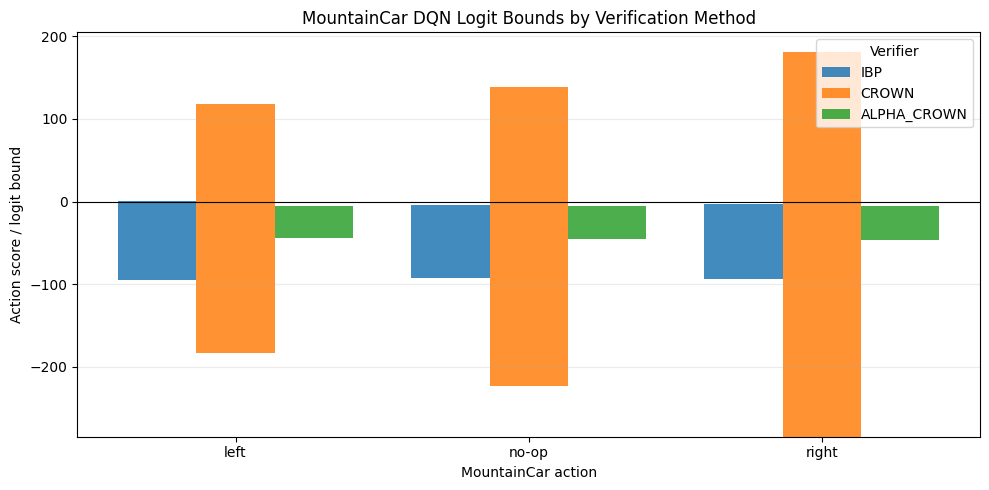

In [7]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["ibp", "crown", "alpha_crown"]

logit_bounds = {}
for method in methods:
    verifier = make_verifier(method)
    logits_l, logits_u = verifier.bound_forward(input_l, input_u)

    logit_bounds[method] = {
        "lower": logits_l.squeeze(0).detach().cpu().numpy(),
        "upper": logits_u.squeeze(0).detach().cpu().numpy(),
    }

n_actions = len(next(iter(logit_bounds.values()))["lower"])
action_labels = ["left", "no-op", "right"] if n_actions == 3 else [f"action {i}" for i in range(n_actions)]

x = np.arange(n_actions)
bar_width = 0.8 / len(methods)

fig, ax = plt.subplots(figsize=(10, 5))

for i, method in enumerate(methods):
    lower = logit_bounds[method]["lower"]
    upper = logit_bounds[method]["upper"]
    height = upper - lower

    offset = (i - (len(methods) - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        height,
        width=bar_width,
        bottom=lower,
        label=method.upper(),
        alpha=0.85,
    )

ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(action_labels)
ax.set_ylabel("Action score / logit bound")
ax.set_xlabel("MountainCar action")
ax.set_title("MountainCar DQN Logit Bounds by Verification Method")
ax.legend(title="Verifier")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Safety finetuning

In [10]:
import copy
import torch
import torch.nn.functional as F

policy_net = dqn_mountaincar.model.q_net.q_net
policy_net.train()

reference_net = copy.deepcopy(policy_net).eval()

def differentiable_ibp_forward(model, x_l, x_u):
    for layer in model:
        if isinstance(layer, torch.nn.Linear):
            W = layer.weight
            b = layer.bias
            W_pos = W.clamp(min=0)
            W_neg = W.clamp(max=0)

            y_l = x_l @ W_pos.T + x_u @ W_neg.T + b
            y_u = x_u @ W_pos.T + x_l @ W_neg.T + b
            x_l, x_u = y_l, y_u

        elif isinstance(layer, torch.nn.ReLU):
            x_l = F.relu(x_l)
            x_u = F.relu(x_u)

        else:
            raise TypeError(f"Unsupported layer: {type(layer)}")

    return x_l, x_u

# MountainCar obs = [position, velocity]
input_l = torch.tensor([[-1.2, -0.07]], dtype=torch.float32)
input_u = torch.tensor([[ -1.0,  0.07]], dtype=torch.float32)

with torch.no_grad():
    center = (input_l + input_u) / 2
    target_action = 2

optimizer = torch.optim.Adam(policy_net.parameters(), lr=1e-4)

desired_margin = 0.1
distill_weight = 0.05

for step in range(2000):
    optimizer.zero_grad()

    logits_l, logits_u = differentiable_ibp_forward(policy_net, input_l, input_u)

    target_lower = logits_l[0, target_action]
    other_upper = torch.cat([
        logits_u[0, :target_action],
        logits_u[0, target_action + 1:],
    ]).max()

    certified_margin = target_lower - other_upper

    # Push target lower bound above every other action's upper bound.
    cert_loss = F.relu(desired_margin - certified_margin)

    # Keep the updated policy close to the original at the interval center.
    with torch.no_grad():
        ref_logits = reference_net(center)
    new_logits = policy_net(center)
    distill_loss = F.mse_loss(new_logits, ref_logits)

    loss = cert_loss + distill_weight * distill_loss
    loss.backward()
    optimizer.step()

    if step % 100 == 0 or certified_margin.item() > desired_margin:
        print(
            f"step={step:04d} "
            f"loss={loss.item():.6f} "
            f"cert_margin={certified_margin.item():.6f}"
        )

    if certified_margin.item() > desired_margin:
        break

policy_net.eval()

step=0000 loss=6.728745 cert_margin=-6.628745


step=0100 loss=6.088016 cert_margin=-5.945074
step=0200 loss=5.610999 cert_margin=-5.361162
step=0300 loss=5.235989 cert_margin=-4.846264
step=0400 loss=4.877329 cert_margin=-4.341874
step=0500 loss=4.576673 cert_margin=-3.906601
step=0600 loss=4.311587 cert_margin=-3.529989
step=0700 loss=4.062316 cert_margin=-3.197041
step=0800 loss=3.815345 cert_margin=-2.897718
step=0900 loss=3.562040 cert_margin=-2.620439
step=1000 loss=3.297083 cert_margin=-2.354146
step=1100 loss=3.017252 cert_margin=-2.088874
step=1200 loss=2.726085 cert_margin=-1.821987
step=1300 loss=2.414567 cert_margin=-1.539034
step=1400 loss=2.080286 cert_margin=-1.233371
step=1500 loss=1.721258 cert_margin=-0.899096
step=1600 loss=1.335336 cert_margin=-0.532038
step=1700 loss=0.921293 cert_margin=-0.128942
step=1753 loss=0.689786 cert_margin=0.100952


Sequential(
  (0): Linear(in_features=2, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=3, bias=True)
)

In [11]:
import copy
import torch
import torch.nn as nn

from abstract_gradient_training.bounded_models import CROWNBoundedModel, IntervalBoundedModel

policy_net.eval()
device = next(policy_net.parameters()).device

# Reuse the same interval used during the update.
# MountainCar obs = [position, velocity]
input_l = torch.tensor([[-1.2, -0.07]], dtype=torch.float32, device=device)
input_u = torch.tensor([[ -1.0,  0.07]], dtype=torch.float32, device=device)

# Verify the action you trained for if target_action exists;
# otherwise use the updated policy's center action.
with torch.no_grad():
    center = (input_l + input_u) / 2
    center_scores = policy_net(center)
    verified_action = globals().get(
        "target_action",
        int(center_scores.argmax(dim=-1).item()),
    )

def make_updated_policy_verifier(method: str):
    model = copy.deepcopy(policy_net).to(device).eval()

    if method == "ibp":
        return IntervalBoundedModel(model, trainable=False)

    if method == "crown":
        return CROWNBoundedModel(
            model,
            trainable=False,
            relu_relaxation="parallel",
        )

    if method == "alpha_crown":
        return CROWNBoundedModel(
            model,
            trainable=False,
            relu_relaxation="optimizable",
            alpha_crown_iters=20,
            alpha_crown_lr=0.1,
        )

    raise ValueError(f"Unknown method: {method}")

def certified_action_margin(logits_l, logits_u, action: int):
    target_lower = logits_l[0, action]
    other_upper = torch.cat([
        logits_u[0, :action],
        logits_u[0, action + 1:],
    ]).max()

    margin = target_lower - other_upper
    return float(margin.detach().cpu()), bool(margin > 0)

print("Verifying updated MountainCar policy")
print("Input lower:", input_l.squeeze(0).tolist())
print("Input upper:", input_u.squeeze(0).tolist())
print("Verified action:", verified_action)
print("Center scores:", center_scores.squeeze(0).detach().cpu().tolist())
print()

for method in ["ibp", "crown", "alpha_crown"]:
    verifier = make_updated_policy_verifier(method)
    logits_l, logits_u = verifier.bound_forward(input_l, input_u)

    margin, certified = certified_action_margin(logits_l, logits_u, verified_action)

    print(f"{method.upper()}")
    print("  lower bounds:", [round(v, 6) for v in logits_l.squeeze(0).detach().cpu().tolist()])
    print("  upper bounds:", [round(v, 6) for v in logits_u.squeeze(0).detach().cpu().tolist()])
    print(f"  certified action stable: {certified}")
    print(f"  certified margin: {margin:.6f}")
    print()

Verifying updated MountainCar policy
Input lower: [-1.2000000476837158, -0.07000000029802322]
Input upper: [-1.0, 0.07000000029802322]
Verified action: 2
Center scores: [-12.851790428161621, -12.873106002807617, -4.902066707611084]

IBP
  lower bounds: [-17.354244, -17.404663, -6.44813]
  upper bounds: [-6.552382, -6.552518, -2.641319]
  certified action stable: True
  certified margin: 0.104251

CROWN
  lower bounds: [-138.415176, -171.421112, -194.571869]
  upper bounds: [101.93457, 117.384399, 141.730865]
  certified action stable: False
  certified margin: -311.956268

ALPHA_CROWN
  lower bounds: [-14.059485, -14.086991, -5.440351]
  upper bounds: [-6.596399, -6.594964, -2.737669]
  certified action stable: True
  certified margin: 1.154613



In [12]:
import sys
sys.path.append(
    '/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning'
)
from projects.safe_crl.utils.gymnasium_utils import plot_episode

ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


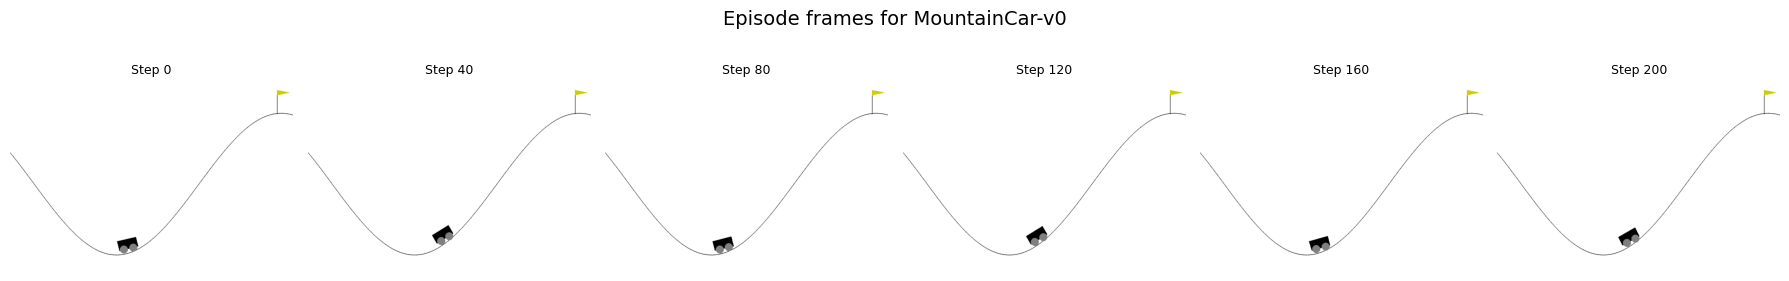

[array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
  

In [13]:
plot_episode(
    actor=policy_net,
    env_id='MountainCar-v0',
    # env: gymnasium.Env | None = None,
    n_cols=6,
    one_row=True,
    # log_std: torch.nn.Parameter | None = None,
    # deterministic: bool = True,
    # seed: int = 42,
    # env_kwargs: dict | None = None,
    # save_path: str | None = None,
    # figsize_per_frame: tuple[float, float] = (3.0, 3.0),
    # title: str | None = None,
)